In [1]:
import random

import torch

from torch import nn
from torch import optim
from torch.utils.data import DataLoader

from torchvision.models import resnet18

import matplotlib.pyplot as plt

from utils.dataset import BaseImageFolderDataset, DomainDataset
from utils.sampler import DomainBatchSampler
from utils.criterion import MMD, Coral
from utils.transforms import base_transforms, train_transforms
from utils.metrics import accuracy
from utils.trainer import train

In [2]:
GPU = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
SEED = 42

TRAIN_FRACTION = 0.01
LEARNING_RATE = 1e-4
BATCH_SIZE = 16

In [3]:
random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# PyTorch backend determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
def plot_training_metrics(metrics_dict):
    """
    Plot training and validation metrics from a dictionary.

    Args:
        metrics_dict: Dictionary containing lists of metrics for each epoch
                      Expected keys: 'train_loss', 'train_acc1', 'train_acc5',
                                   'val_loss', 'val_acc1', 'val_acc5'
    """
    epochs = range(1, len(metrics_dict['train_loss']) + 1)

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Loss curves
    ax1.plot(epochs, metrics_dict['train_loss'],
             'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, metrics_dict['val_loss'],
             'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy curves (Top-1 and Top-5)
    ax2.plot(epochs, metrics_dict['train_acc1'],
             'b-', label='Train Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['val_acc1'],
             'r-', label='Val Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['train_acc5'], 'b--',
             label='Train Top-5', linewidth=2, alpha=0.7)
    ax2.plot(epochs, metrics_dict['val_acc5'], 'r--',
             label='Val Top-5', linewidth=2, alpha=0.7)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [5]:
class VisDA2017Source(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/train.tar'
    ARCHIVE_NAME = 'train.tar'
    EXTRACTED_FOLDER = 'train'


class VisDA2017Target(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/test.tar'
    ARCHIVE_NAME = 'test.tar'
    EXTRACTED_FOLDER = 'test'


class VisDA2017Validation(BaseImageFolderDataset):
    URL = ' http://csr.bu.edu/ftp/visda17/clf/validation.tar'
    ARCHIVE_NAME = 'validation.tar'
    EXTRACTED_FOLDER = 'validation'

In [6]:
source_dataset = VisDA2017Source(
    './data', transform=train_transforms, download=True
)

target_dataset = VisDA2017Target(
    './data', transform=base_transforms, download=True
)

val_dataset = VisDA2017Validation(
    './data', transform=base_transforms, download=True
)

In [7]:
len(source_dataset), len(target_dataset), len(val_dataset)

(152397, 72372, 55388)

In [8]:
# TODO: Delete after tesing utils

import numpy as np
from torch.utils.data import Subset

np.random.seed(42)

# Generate random indices for split
source_indices = np.arange(len(source_dataset))
target_indices = np.arange(len(target_dataset))
val_indices = np.arange(len(val_dataset))

np.random.shuffle(source_indices)
np.random.shuffle(target_indices)
np.random.shuffle(val_indices)

source_size = int(len(source_dataset) * TRAIN_FRACTION)
target_size = int(len(target_dataset) * TRAIN_FRACTION)
val_size = int(len(val_dataset) * TRAIN_FRACTION)

source_indices = list(source_indices[:source_size])
target_indices = list(target_indices[:target_size])
val_indices = list(val_indices[:val_size])

source_dataset = Subset(source_dataset, source_indices)
target_dataset = Subset(target_dataset, target_indices)
val_dataset = Subset(val_dataset, val_indices)

In [9]:
train_dataset = DomainDataset(source_dataset, target_dataset)

train_sampler = DomainBatchSampler(
    source_size=len(source_dataset),
    target_size=len(target_dataset),
    batch_size=BATCH_SIZE,
)

In [10]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_sampler=train_sampler,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

In [11]:
import torch.nn.functional as F


class Criterion(nn.Module):
    def __init__(self, model, lambda_mmd: float = 0.5):
        super().__init__()
        self.model = model
        self.lambda_mmd = lambda_mmd

        self.ce = torch.nn.CrossEntropyLoss()
        self.mmd = MMD()
        self.coral = Coral()

    def forward(self, pred: torch.Tensor, y: torch.Tensor):
        mask = y != -1

        cls_loss = self.ce(pred[mask], y[mask])

        mmd = torch.tensor(0, device=y.device)
        # coral = torch.tensor(0, device=y.device)

        if (~mask).sum() > 0:
            features = self.model._features

            feat_s = features[mask]
            feat_t = features[~mask]

            mmd = self.mmd(feat_s, feat_t)
            # coral = self.coral(feat_s, feat_t)

        return cls_loss + self.lambda_mmd * mmd


def metrics_with_mask(orig_metrics_fn):
    def wrapped(pred, y):
        mask = (y != -1)
        if mask.sum() == 0:
            zeroed = {k: 0.0 for k in orig_metrics_fn(torch.zeros(
                1, pred.size(1)), torch.zeros(1, dtype=torch.long)).keys()}
            return zeroed
        return orig_metrics_fn(pred[mask], y[mask])

    return wrapped

In [12]:
model = resnet18(num_classes=12)


def store_features(module, input, output):
    model._features = torch.flatten(output, 1)


model.avgpool.register_forward_hook(store_features)

In [13]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [14]:
loss = Criterion(model, lambda_mmd=0.5)

In [15]:
metrics = train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    loss,
    metrics_with_mask(accuracy),
    epochs=10,
    # start_epoch=0,
    checkpoint_interval=20,
    checkpoint_path='.',
    device=GPU
)

Epoch   1 | Train Loss: 2.7415 | Train acc1: 19.4079 | Train acc5: 63.6184 | Val Loss: 2.5095 | Val acc1: 9.6032 | Val acc5: 54.1865


Epoch   2 | Train Loss: 2.4677 | Train acc1: 23.9474 | Train acc5: 76.7763 | Val Loss: 2.5178 | Val acc1: 13.0357 | Val acc5: 59.3651


Epoch   3 | Train Loss: 2.3564 | Train acc1: 29.4737 | Train acc5: 79.8684 | Val Loss: 2.5426 | Val acc1: 14.4246 | Val acc5: 59.9802


Epoch   4 | Train Loss: 2.2526 | Train acc1: 33.8158 | Train acc5: 82.5658 | Val Loss: 2.5412 | Val acc1: 13.1349 | Val acc5: 57.5794


Epoch   5 | Train Loss: 2.2013 | Train acc1: 35.7237 | Train acc5: 83.2895 | Val Loss: 2.4963 | Val acc1: 12.6389 | Val acc5: 57.6587


Epoch   6 | Train Loss: 2.1318 | Train acc1: 39.6053 | Train acc5: 86.1184 | Val Loss: 3.1101 | Val acc1: 7.2421 | Val acc5: 41.9444


Epoch   7 | Train Loss: 2.0466 | Train acc1: 42.6974 | Train acc5: 86.6447 | Val Loss: 2.9433 | Val acc1: 8.8095 | Val acc5: 56.9048


Epoch   8 | Train Loss: 2.0210 | Train acc1: 45.3947 | Train acc5: 87.3026 | Val Loss: 3.0458 | Val acc1: 7.9960 | Val acc5: 52.4802


Epoch   9 | Train Loss: 1.9811 | Train acc1: 44.2763 | Train acc5: 87.9605 | Val Loss: 3.0834 | Val acc1: 11.4881 | Val acc5: 47.0833


Epoch  10 | Train Loss: 1.9366 | Train acc1: 45.7237 | Train acc5: 88.0921 | Val Loss: 2.8366 | Val acc1: 8.9881 | Val acc5: 53.1548


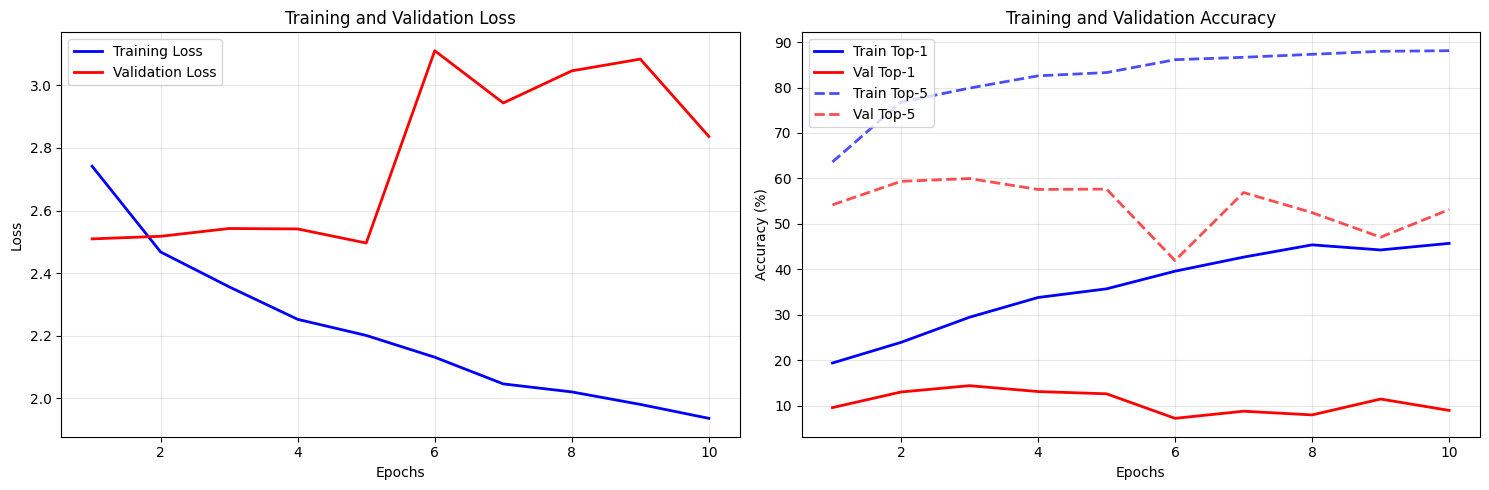

In [16]:
plot_training_metrics(metrics)